In [2]:
import json
import os
root_dir = "/fs/archive/share/mm_datasets/MMQA/MMQA"


In [5]:
split = "dev"
dataset = []
with open(os.path.join(root_dir, f"multimodalqa_final_dataset_pipeline_camera_ready_MMQA_{split}.jsonl"), "r") as f:
    for line in f:
        data = json.loads(line)
        dataset.append(data)

In [8]:
split = "tables"
dataset = []
with open(os.path.join(root_dir, f"multimodalqa_final_dataset_pipeline_camera_ready_MMQA_{split}.jsonl"), "r") as f:
    for line in f:
        data = json.loads(line)
        dataset.append(data)

In [ ]:
print(json.dumps(dataset[0], indent=4))

In [ ]:
from tabulate import tabulate

def convert_mmqa_table_to_string(data):
    header = [col['column_name'] if col['column_name'] else "" for col in data['table']['header']]
    rows = []

    for row in data['table']['table_rows']:
        new_row = [cell['text'] for cell in row]
        rows.append(new_row)

    table_str = tabulate(rows, headers=header, tablefmt='grid')
    return table_str


In [12]:
str = convert_mmqa_table_to_string(dataset[0])
print(str)

+--------+----------------------------+------------+----+---------------------+------------+---------+-------+----+------------------------+------------+---------+-------+
|   Year | Office                     | Election   |    | Subject             | Party      | Votes   | %     |    | Opponent               | Party      | Votes   | %     |
+========+============================+============+====+=====================+============+=========+=======+====+========================+============+=========+=======+
|   1994 | Baltimore County Executive | General    |    | Dutch Ruppersberger | Democratic | N/A     | N/A   |    | N/A                    | N/A        | N/A     | N/A   |
+--------+----------------------------+------------+----+---------------------+------------+---------+-------+----+------------------------+------------+---------+-------+
|   1998 | Baltimore County Executive | General    |    | Dutch Ruppersberger | Democratic | 166,482 | 70.47 |    | John J. Bishop         |

In [19]:
split = "dev"
dataset = []
with open(os.path.join(root_dir, f"multimodalqa_final_dataset_pipeline_camera_ready_MMQA_{split}.jsonl"), "r") as f:
    for line in f:
        data = json.loads(line)
        dataset.append(data)

In [21]:
print(json.dumps(dataset[1], indent=4))

{
    "qid": "710a6d2254076ea58756c6c7cc211f1e",
    "question": "When was the movie that had Ben Piazza in the role of Bob Whitewood released?",
    "answers": [
        {
            "answer": "1976",
            "type": "string",
            "modality": "text",
            "text_instances": [
                {
                    "doc_id": "5346073795a986f7bbbacbd4b197a787",
                    "part": "text",
                    "start_byte": 24,
                    "text": "1976"
                }
            ],
            "table_indices": [],
            "image_instances": []
        }
    ],
    "metadata": {
        "type": "Compose(TextQ,TableQ)",
        "modalities": [
            "table",
            "text"
        ],
        "wiki_entities_in_question": [],
        "wiki_entities_in_answers": [],
        "pseudo_language_question": "when did  {the [Title](s) in the [Filmography] of [Ben Piazza] when the [Role] was [Bob Whitewood]}, come out",
        "rephrasing_meta": {


In [5]:
import json
from PIL import Image, UnidentifiedImageError
import os

with open("mmqa_corpus.json", "r") as f:
    mmqa_corpus = json.load(f)

root_dir = "/fs/archive/share/mm_datasets/downloads/MMQA/final_dataset_images"
error_images = []  # 存储无法打开的图片路径

for item in mmqa_corpus:
    if item['image'] != "":
        image_path = os.path.join(root_dir, item['image'])
        try:
            # 尝试打开图片
            with Image.open(image_path) as img:
                img.verify()  # 验证图片完整性（可选）
        except (UnidentifiedImageError, IOError) as e:
            print(f"Error opening image: {image_path} - {str(e)}")
            error_images.append(image_path)

# 打印所有有问题的图片路径
print("\nList of corrupted/invalid images:")
for img_path in error_images:
    print(img_path)

print(f"\nTotal corrupted images: {len(error_images)}")

/home/u2024001042/.conda/envs/mrag/lib/python3.11/site-packages/PIL/Image.py:3442: DecompressionBombWarning: Image size (129967200 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Error opening image: /fs/archive/share/mm_datasets/downloads/MMQA/final_dataset_images/17ae0616ac745e70781203267f3a382d.jpg - cannot identify image file '/fs/archive/share/mm_datasets/downloads/MMQA/final_dataset_images/17ae0616ac745e70781203267f3a382d.jpg'
Error opening image: /fs/archive/share/mm_datasets/downloads/MMQA/final_dataset_images/bf201cbbd058ef51aef89b1be4158c2a.jpg - cannot identify image file '/fs/archive/share/mm_datasets/downloads/MMQA/final_dataset_images/bf201cbbd058ef51aef89b1be4158c2a.jpg'
Error opening image: /fs/archive/share/mm_datasets/downloads/MMQA/final_dataset_images/ef457a7b3ab437cd78ab9f82dc083048.jpg - cannot identify image file '/fs/archive/share/mm_datasets/downloads/MMQA/final_dataset_images/ef457a7b3ab437cd78ab9f82dc083048.jpg'
Error opening image: /fs/archive/share/mm_datasets/downloads/MMQA/final_dataset_images/225c3db49d60b5ef30ed0bfc649ebf78.jpg - cannot identify image file '/fs/archive/share/mm_datasets/downloads/MMQA/final_dataset_images/225c3d

In [2]:
def lower(text):
    return str(text).lower()

a = 33.21
print(lower(a))

33.21


In [30]:
from PIL import Image
image = Image.open("/fs/archive/share/mm_datasets/MMQA/images/170294000809b7bd27260c83ee2f9ffc.jpg")

Image size (W x H): (243, 411)
Image array shape: (411, 243, 4)
Num channels: 4


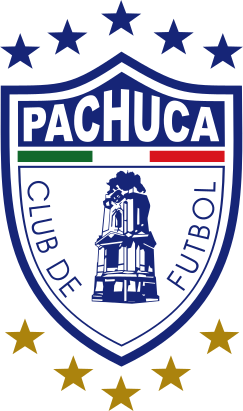

In [32]:
import numpy as np

image = Image.open("/fs/archive/share/mm_datasets/MMQA/images/170294000809b7bd27260c83ee2f9ffc.jpg")
image_array = np.array(image)

print(f"Image size (W x H): {image.size}")  # PIL 的 image.size 是 (width, height)
print(f"Image array shape: {image_array.shape}")

if image_array.ndim == 2:
    print("Num channels: 1 (grayscale)")
elif image_array.ndim == 3:
    print(f"Num channels: {image_array.shape[2]}")
else:
    print("Unexpected image shape.")
display(image)

In [37]:
image = Image.open("/fs/archive/share/mm_datasets/MMQA/images/05c22ad2e040d8392758540f0d9ee39a.png")
image = image.resize((100, 4))  # Resize to (width, height)
image_array = np.array(image)

print(f"Image size (W x H): {image.size}")  # PIL 的 image.size 是 (width, height)
print(f"Image array shape: {image_array.shape}")

if image_array.ndim == 2:
    print("Num channels: 1 (grayscale)")
elif image_array.ndim == 3:
    print(f"Num channels: {image_array.shape[2]}")
else:
    print("Unexpected image shape.")
display(image)

Image size (W x H): (100, 4)
Image array shape: (4, 100, 3)
Num channels: 3


In [41]:
import torch
import json
import os
import numpy as np

from tqdm import tqdm

from PIL import Image
from transformers import CLIPProcessor, CLIPModel

model_name = "/fs/archive/share/clip-vit-base-patch32"
corpus_path = "/home/u2024001042/workspace/nyx-cc/baselines/mmqa/mmqa_corpus_with_captions.json"

processor = CLIPProcessor.from_pretrained(
    model_name,
    use_fast=True)

with open(corpus_path, "r") as f:
    corpus = json.load(f)

for item in tqdm(corpus, desc="Processing corpus"):
    if item['image'] != "":
        image_path = os.path.join("/fs/archive/share/mm_datasets/MMQA/images", item['image'])
        if item['image'] != "":
            image = Image.open(image_path).convert("RGBA")
            width, height = image.size
            if width < 4:
                image = image.resize((4, height))
            if height < 4:
                image = image.resize((width, 4))
            try:
                images_inputs = processor(
                    images=image, 
                    return_tensors="pt",
                    truncation=True,
                )
            except Exception as e:
                print(image.shape)
                print(f"Error processing image {image_path}: {e}")
                continue

Processing corpus:   1%|          | 1790/285370 [00:19<51:20, 92.04it/s]  


KeyboardInterrupt: 